In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -qq langchain-groq langchain langchain-core langchain-community langgraph

# LLM Setup

In [3]:
from kaggle_secrets import UserSecretsClient
from langchain_groq import ChatGroq

# Securely fetch the key from Kaggle's secret storage
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GROQ_API_KEY")

llm = ChatGroq(
    model='llama-3.3-70b-versatile',
    api_key=api_key
)

In [4]:
print((llm.invoke("what is the value of sin30")).content)

The value of sin(30°) is 0.5 or 1/2.


## Libraries

In [5]:
from typing import TypedDict, Literal, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image
from pydantic import BaseModel, Field
import random

# Parallel Workflow

In [6]:
class content(TypedDict):
    idea : str
    blog : str
    linkedin_post : str
    tweet : str

In [7]:
def blog(state : content):
    prompt = f"""
    You are a content writer. Generate blog content (about 300 words) based on the given idea.
    Use formatting wherever necessary.
    Idea : {state['idea']}
    """

    blog_content = llm.invoke(prompt)
    return {'blog':blog_content.content}


def linkedin_post(state : content):
    prompt = f"""
    You are a content writer. Generate content for a linkedin post based on the given idea.
    Keep the content professional and use '#' for key terms.
    Idea : {state['idea']}
    """

    linkedin_content = llm.invoke(prompt)
    return {'linkedin_post':linkedin_content.content}



def tweet(state : content):
    prompt = f"""
    You are a content writer. Generate content for a tweet based on the given idea.
    Kepp the content short and stick to the topic.
    Idea : {state['idea']}
    """

    tweet_content = llm.invoke(prompt)
    return {'tweet':tweet_content.content}

In [8]:
graph = StateGraph(content)

graph.add_node('blog',blog)
graph.add_node('linkedin_post',linkedin_post)
graph.add_node('tweet',tweet)

graph.add_edge(START, 'blog')
graph.add_edge(START, 'linkedin_post')
graph.add_edge(START, 'tweet')
graph.add_edge('blog', END)
graph.add_edge('linkedin_post', END)
graph.add_edge('tweet', END)

workflow = graph.compile()

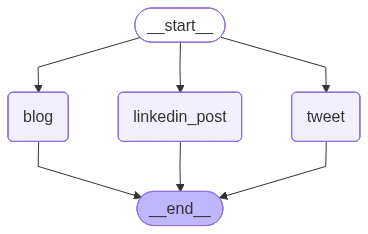

In [9]:
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
idea = {'idea':"The 'State' of the Art - Why LangGraph Beats Linear Chains"}
result = workflow.invoke(idea)
for key,value in result.items():
    print(f"\n{'-'*50}\n{key.upper()}\n{'-'*50}")
    print(f"{value}")


--------------------------------------------------
IDEA
--------------------------------------------------
The 'State' of the Art - Why LangGraph Beats Linear Chains

--------------------------------------------------
BLOG
--------------------------------------------------
**The 'State' of the Art - Why LangGraph Beats Linear Chains**

The world of Natural Language Processing (NLP) has witnessed significant advancements in recent years. One of the most notable developments is the emergence of **LangGraph**, a revolutionary approach that surpasses traditional linear chains in language modeling. In this blog, we'll delve into the details of LangGraph and explore why it outshines linear chains.

**What are Linear Chains?**
-------------------------

Linear chains refer to the traditional approach of processing language as a sequence of words, one after the other. This approach has been widely used in NLP tasks such as language modeling, text classification, and machine translation. Howev

# Conditional Workflows

In [11]:
class QuadEqState(TypedDict):
    a:int
    b:int
    c:int
    equation : str
    discriminant : float
    result : str

In [12]:
def show_eq(state: QuadEqState):
    eq = f"{state['a']}x**2 + ({state['b']})x + ({state['c']})"
    return {'equation':eq}

def cal_discriminant(state : QuadEqState):
    d = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant':d}

def real_roots(state : QuadEqState):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])

    result = f"The roots are : {root1:.3f},{root2:.3f}"
    return {'result':result}

def repeated_roots(state : QuadEqState):
    root = -state['b']/(2*state['a'])
    result = f"Repeated roots : {root}"
    return {'result':result}

def no_real_roots(state : QuadEqState):
    result = "No real roots"
    return {'result':result}

def check_condition(state : QuadEqState) -> Literal["real_roots","repeated_roots","no_real_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [13]:
graph = StateGraph(QuadEqState)

graph.add_node('show_eq', show_eq)
graph.add_node('cal_discriminant', cal_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START,'show_eq')
graph.add_edge('show_eq', 'cal_discriminant')
graph.add_conditional_edges('cal_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()

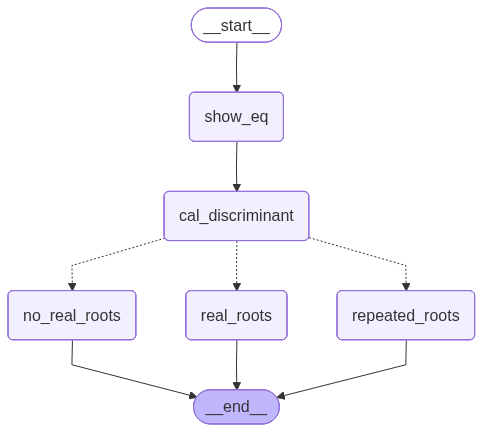

In [14]:
Image(workflow.get_graph().draw_mermaid_png())

In [15]:
initial_state = [
    {"a": 1, "b": 2, "c": 6},
    {"a": 4, "b": -12, "c": 9},
    {"a": 2, "b": 8, "c": 4}
]

for i, state in enumerate(initial_state, 1):
    print(f"{'-'*30}\nTest Case {i}\n{'-'*30}")
    result = workflow.invoke(state)

    for key, val in result.items():
        print(f"{key}: {val}")

------------------------------
Test Case 1
------------------------------
a: 1
b: 2
c: 6
equation: 1x**2 + (2)x + (6)
discriminant: -20
result: No real roots
------------------------------
Test Case 2
------------------------------
a: 4
b: -12
c: 9
equation: 4x**2 + (-12)x + (9)
discriminant: 0
result: Repeated roots : 1.5
------------------------------
Test Case 3
------------------------------
a: 2
b: 8
c: 4
equation: 2x**2 + (8)x + (4)
discriminant: 32
result: The roots are : -0.586,-3.414


# Iterative Workflows

In [16]:
class NumberGuessState(TypedDict):
    target: int
    current_guess: int
    feedback: str
    attempts: int
    history: List[str]

In [17]:
import re

def guesser(state: NumberGuessState):
    # Retrieve history or start fresh
    history_log = state.get('history', [])
    history_str = "\n".join(history_log) if history_log else "No guesses yet."
    
    prompt = f"""
    You are playing a 'Higher or Lower' game. 
    Target: A secret 2-digit number (00-99).
    
    Your History:
    {history_str}
    
    Current Task: 
    Analyze your previous guesses and the feedback. 
    Logical Reasoning: If your guess was 50 and the feedback was 'Higher', your next guess MUST be between 51 and 99.
    
    Provide your next guess as a single 2-digit number.
    Result:
    """
    
    response = llm.invoke(prompt)
    content = response.content.strip()
    
    # Extract the first number found in the LLM's response
    match = re.search(r'\d+', content)
    clean_guess = int(match.group()) if match else 50
        
    return {
        "current_guess": clean_guess, 
        "attempts": state['attempts'] + 1
    }

In [18]:
def evaluator(state: NumberGuessState):
    guess = state['current_guess']
    target = state['target']
    
    if guess < target:
        result = "Higher"
    elif guess > target:
        result = "Lower"
    else:
        result = "Correct"
        
    old_history = state.get('history', [])
    new_entry = f"Guess {state['attempts']}: {guess} (Feedback: {result})"
    updated_history = old_history + [new_entry]

    #return updated hostory
    return {
        "feedback": result,
        "history": updated_history
    }

In [19]:
def check_win(state: NumberGuessState):
    if state["feedback"] == "Correct":
        return "won"
    if state["attempts"] >= 5:
        return "out_of_turns"
    return "try_again"

builder = StateGraph(NumberGuessState)
builder.add_node("guesser", guesser)
builder.add_node("evaluator", evaluator)

builder.add_edge(START, "guesser")
builder.add_edge("guesser", "evaluator")

builder.add_conditional_edges(
    "evaluator",
    check_win,
    {
        "try_again": "guesser",
        "won": END,
        "out_of_turns": END
    }
)

game_app = builder.compile()

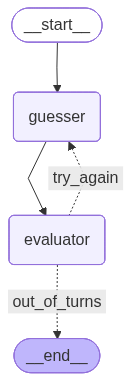

In [20]:
game_app

In [21]:
# Updated inputs to include the empty history list
inputs = {
    "target":67, 
    "attempts": 0, 
    "feedback": "",
    "history": []
}

for output in game_app.stream(inputs):
    for key, value in output.items():
        if key == "guesser":
            print(f"LLM Guessed: {value.get('current_guess')}")
        elif key == "evaluator":
            print(f"Feedback: {value.get('feedback')}")
            print("-" * 30)

LLM Guessed: 50
Feedback: Higher
------------------------------
LLM Guessed: 50
Feedback: Higher
------------------------------
LLM Guessed: 50
Feedback: Higher
------------------------------
LLM Guessed: 50
Feedback: Higher
------------------------------
LLM Guessed: 50
Feedback: Higher
------------------------------
